# PyTorch MLP driver for O2 gapfill (GPU)
- Standalone companion to `o2_train.ipynb`, focused purely on replacing the sklearn `MLPRegressor` with a native PyTorch MLP trained on GPU.
- Reuses the exact same data pipeline as `o2_train.ipynb` (config, basin/predictor selection, depth subsetting, leak-safe train/test split, decadal K-fold definition) so results are comparable; only the model-training cells differ.
- `o2_train.ipynb` itself is untouched by this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os
import warnings
import torch
import torch.nn as nn
from IPython.display import clear_output, display
warnings.filterwarnings('ignore')

In [2]:
usrid = os.environ['USER']
scratch = f'{os.environ["HOME"]}/scratch'
data_root = f'{os.environ["HOME"]}/data/data/ocean'
os.system(f'mkdir -p {scratch}/ML4O2_temp/')
os.system(f'mkdir -p {scratch}/ML4O2_results/')
os.system(f'mkdir -p {scratch}/WOD18_OSDCTD/')
#
# version information - must match the basin/predictor/data-source digits you want;
# the 1st (algorithm) and 6th (hyperparameter-search) digits are not used by this notebook
ver = '2.3.1.4.6.4'
#
# random seed used throughout (train/test split, model init) for reproducibility;
# vary this across runs to generate ensemble members
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
#
dirout=f'{scratch}/ML4O2_temp/'
dirfin=f'{scratch}/ML4O2_results/'
#
# max depth (meters): subset to shallow samples for fast iteration; set to a large
# value (e.g. 6000) to use the full water column
max_depth = 1000.
#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
NVIDIA A100-PCIE-40GB


In [3]:
selection = ver.split('.')
basin = ['atlantic','pacific','indian','southern','arctic',\
         'mediterranean','baltic','black','red','persian',\
         'hudson','japan-east','caspian']
#
print(basin[int(selection[2])-1]+' will be mapped')
#
if selection[3] == '1':
    print('EN4 dataset will be used for T/S input. ')
    endyear=2021
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_20250708'
elif selection[3] == '2':
    print('ORAS4 dataset will be used for T/S input. ')
    endyear=2018
elif selection[3] == '3':
    print('SODA3.4.2 dataset will be used for T/S input. ')
elif selection[3] == '4':
    print('EN4 (C14) dataset will be used for T/S input. ')
    endyear=2025
    if selection[1]=='1':
        dirinput = f'{data_root}/ML4O2/input_20250822/'
    elif selection[1]=='2':
        dirinput = f'{data_root}/ML4O2/input_20250708/'
    elif selection[1]=='3':
        dirinput = f'{data_root}/ML4O2/input_202602/'
    Nlev=102
else:
    print('error - incorrect T/S data type')
#
if selection[4] == '1':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, month')
elif selection[4] == '2':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month)')
elif selection[4] == '3':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma')
elif selection[4] == '4':
    print('Predictor variables include T, S, lon, lat, depth (pressure), year, cos(month), sin(month), sigma, N2')
elif selection[4] == '5':
    print('Predictor variables include T, S, lon, lat, depth (pressure), cos(month), sin(month)')
elif selection[4] == '6':
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
else:
    print('error - incorrect predictor variable type')

atlantic will be mapped
EN4 (C14) dataset will be used for T/S input. 
Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)


In [4]:
# Define the input and output folders
dirin = f'{data_root}/WOD_O2_2022-25/'
fosd='_1x1bin_osd_'
os.system(f'mkdir -p {scratch}/WOD18_OSDCTD/')

0

In [5]:
# select analysis period
# do not change the start year from 1965 (this is when Carpenter 1965 established modern Winkler method)
yrs=np.arange(1965,endyear+1,1)

In [6]:
# basin-specific input data loading
bname0=basin[int(selection[2])-1]
#
if selection[3]=='4':
    doa1 = np.load(f'{dirinput}/o20_{bname0}_1x1_{Nlev}lev.npy')
    dta1 = np.load(f'{dirinput}/t0_{bname0}_1x1_{Nlev}lev.npy')
    dsa1 = np.load(f'{dirinput}/s0_{bname0}_1x1_{Nlev}lev.npy')
    xx1 = np.load(f'{dirinput}/lon0_{bname0}_1x1_{Nlev}lev.npy')
    yy1 = np.load(f'{dirinput}/lat0_{bname0}_1x1_{Nlev}lev.npy')
    zz1 = np.load(f'{dirinput}/depth0_{bname0}_1x1_{Nlev}lev.npy')
    tt1 = np.load(f'{dirinput}/time0_{bname0}_1x1_{Nlev}lev.npy')
    tc1 = np.load(f'{dirinput}/month0_{bname0}_1x1_{Nlev}lev.npy')
    GMT1 = np.load(f'{dirinput}/GMT0_{bname0}_1x1_{Nlev}lev.npy')
else:
    raise NotImplementedError('This notebook currently mirrors only the selection[3]==4 (EN4 C14) data-loading branch used in o2_train.ipynb; port the other branches from there if needed.')

In [7]:
z_mask = np.where(zz1 <= max_depth,True,False)
Nsample_total = np.size(doa1)
Nsample = np.sum(z_mask)
print(Nsample_total, Nsample, Nsample/Nsample_total)

4443293 3422576 0.770279160073396


In [8]:
# generate data matrix (kept unnormalized here; normalization is fit on the training split only, see next cell)
if selection[4] == '6':
    X = np.array([dsa1, dta1, xx1, yy1, zz1, GMT1, np.cos(2*np.pi*tc1/12), np.sin(2*np.pi*tc1/12)])
    print('Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)')
else:
    raise NotImplementedError('Port the other selection[4] branches from o2_train.ipynb if needed.')
X = X[:,z_mask].T
y = doa1[z_mask]
N = np.size(y)
print(np.shape(X))

Predictor variables include T, S, lon, lat, depth (pressure), GMT, cos(month), sin(month)
(3422576, 8)


## Train/test split and decadal K-fold
- Identical logic to `o2_train.ipynb`: 11 random years held out as the outer test set, standardization fit on the training partition only (no leakage), then a 5-fold decadal grouping of the training set for hyperparameter search.

In [9]:
# determine which years to hold out as test data
yr_drop = np.random.choice(yrs,11,replace=False)
print(yr_drop)

# group these years together into a single test mask
yr1_full=np.round(tt1[z_mask]/12+1965)
ind=(yr1_full==yr_drop[0])
for n in np.arange(1,11,1):
    tmp=(yr1_full==yr_drop[n])
    ind=(ind==True)|(tmp==True)
ind1 = (ind==False)
print(f'the count of data point (bins) = {yr1_full.size}')
print(f'the count of test data (bins) = {np.sum(ind)}, which is {np.sum(ind)/yr1_full.size*100}%')

# normalize using training-set statistics only (avoids test-set leakage into Xm/Xstd/ym/ystd)
Xm = np.mean(X[ind1,:],axis=0)
Xstd = np.std(X[ind1,:],axis=0)
ym = np.mean(y[ind1])
ystd = np.std(y[ind1])
Xa = (X - Xm)/Xstd
ya = (y-ym)/ystd

X_train = Xa[ind1,:]
X_test = Xa[ind,:]
y_train = ya[ind1]
y_test = ya[ind]
print(f'the count of train data point (bins) = {y_train.size}')

# Decadal Group K-fold
tbnds=[1965,1977,1989,2000,2012,2022]
tt1z = tt1[z_mask]
yr1 = tt1z[ind1]/12+1965
print(f'The total count of data points = {yr1.size}')
for n in range(5):
    K_test=(yr1>=tbnds[n])&(yr1<tbnds[n+1])
    K_train=(K_test==False)
    print(f'Group {n} train size = {np.sum(K_train)}, test size = {np.sum(K_test)}, {np.sum(K_test)/y_train.size*100:.1f}%')

[1991 2000 2025 1993 1976 1967 1999 2024 2005 1987 1969]
the count of data point (bins) = 3422576
the count of test data (bins) = 593088, which is 17.328702123780452%


the count of train data point (bins) = 2829488
The total count of data points = 2829488
Group 0 train size = 2346749, test size = 482739, 17.1%
Group 1 train size = 2084793, test size = 744695, 26.3%
Group 2 train size = 2571899, test size = 257589, 9.1%
Group 3 train size = 2468567, test size = 360921, 12.8%
Group 4 train size = 2111900, test size = 717588, 25.4%


## EDA
- Distributions of the target and each predictor, and a correlation table, computed on the training split only (`ind1` mask) to avoid any peeking at the outer test set.
- Followed by an OLS multiple linear regression baseline (see below) with partial dependence plots.

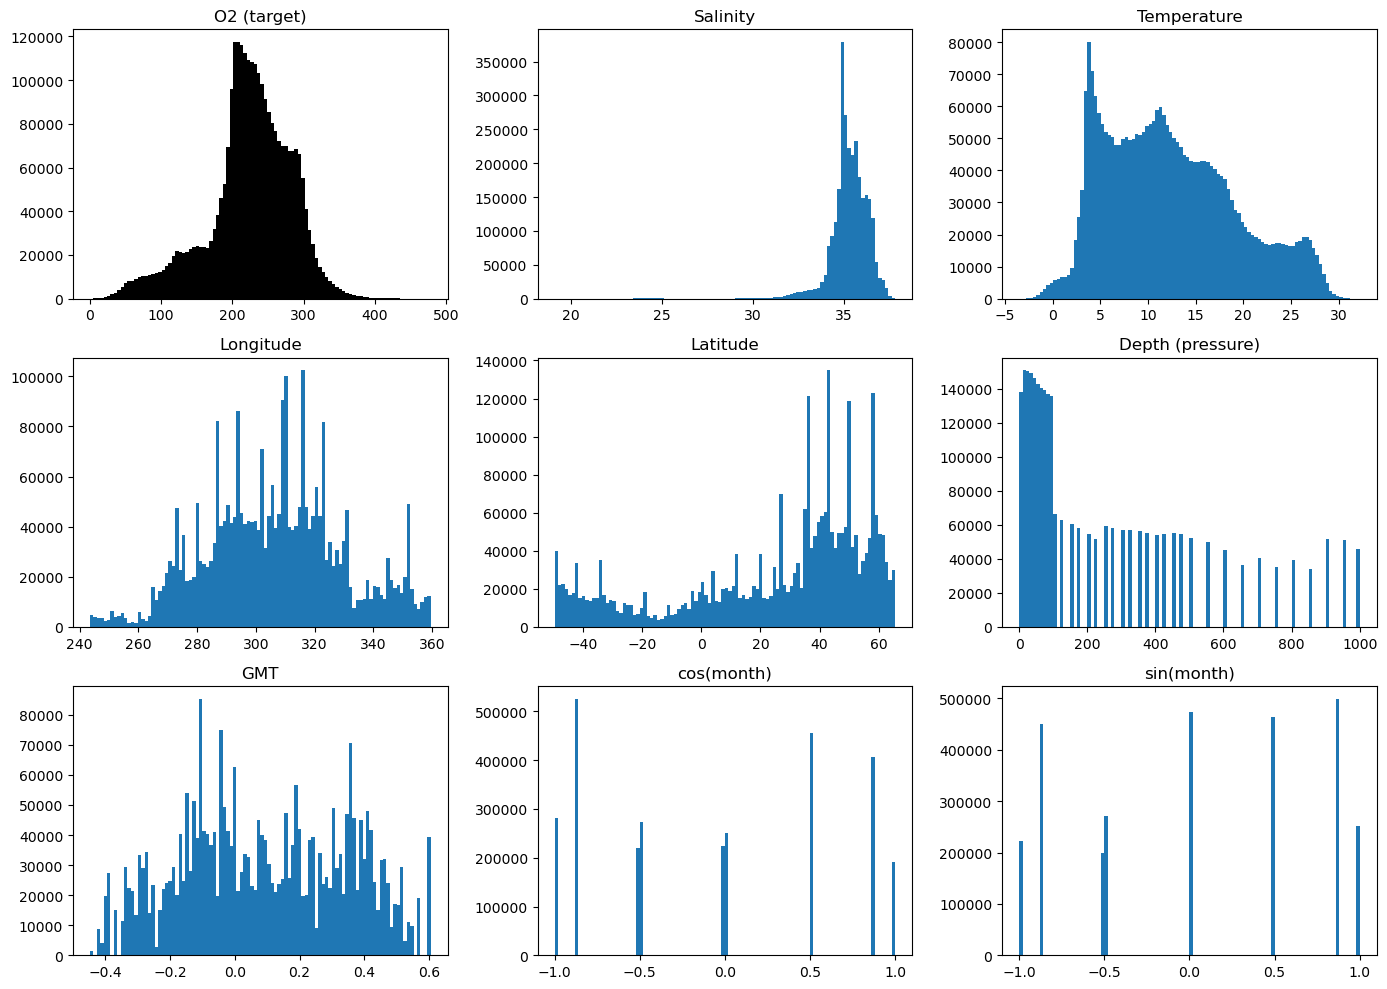

In [10]:
feature_names = ['Salinity', 'Temperature', 'Longitude', 'Latitude', 'Depth (pressure)', \
                  'GMT', 'cos(month)', 'sin(month)']

# raw (unstandardized) train-split values, reused by the EDA/linear-regression cells below
X_train_eda = X[ind1, :]
y_train_eda = y[ind1]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
axes[0].hist(y_train_eda, bins=100, color='k')
axes[0].set_title('O2 (target)')
for i, name in enumerate(feature_names):
    axes[i+1].hist(X_train_eda[:, i], bins=100, color='tab:blue')
    axes[i+1].set_title(name)
for ax in axes[len(feature_names)+1:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('Fig_EDA_distributions.pdf')
plt.show()

,Salinity,Temperature,Longitude,Latitude,Depth (pressure),GMT,cos(month),sin(month),O2
Salinity,1.000,0.644,-0.053,-0.006,-0.108,-0.097,0.040,0.028,-0.317
Temperature,0.644,1.000,-0.060,-0.186,-0.470,-0.171,0.024,-0.036,-0.341
Longitude,-0.053,-0.060,1.000,-0.283,-0.014,0.047,0.012,0.004,-0.118
Latitude,-0.006,-0.186,-0.283,1.000,-0.028,-0.087,-0.110,-0.004,0.343
Depth (pressure),-0.108,-0.470,-0.014,-0.028,1.000,0.125,0.011,0.001,-0.252
GMT,-0.097,-0.171,0.047,-0.087,0.125,1.000,-0.009,-0.037,0.092
cos(month),0.040,0.024,0.012,-0.110,0.011,-0.009,1.000,-0.006,-0.045
sin(month),0.028,-0.036,0.004,-0.004,0.001,-0.037,-0.006,1.000,0.033
O2,-0.317,-0.341,-0.118,0.343,-0.252,0.092,-0.045,0.033,1.000


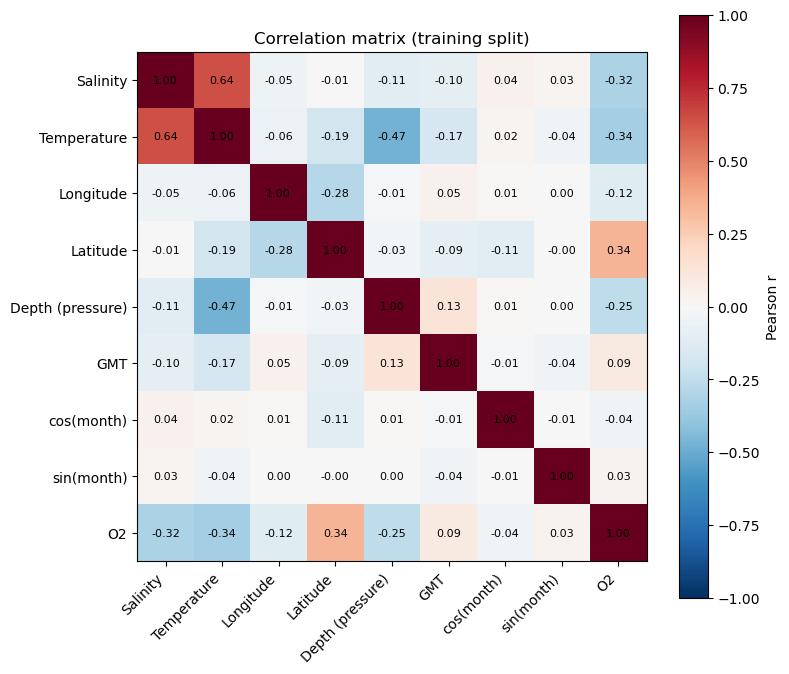

In [11]:
import pandas as pd

df_eda = pd.DataFrame(X_train_eda, columns=feature_names)
df_eda['O2'] = y_train_eda
corr = df_eda.corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Correlation matrix (training split)')
plt.tight_layout()
plt.savefig('Fig_EDA_correlation.pdf')
plt.show()

### Multiple linear regression baseline
- OLS fit on the same 8 predictors, in physical (unstandardized) units, as a simple interpretable baseline for the nonlinear MLP models below.
- Uses the same outer train/test split as the MLP experiments (`ind1`/`ind` masks), so R2/RMSE are directly comparable.

In [12]:
from sklearn.linear_model import LinearRegression

X_test_lr = X[ind, :]
y_test_lr = y[ind]

lr_model = LinearRegression()
lr_model.fit(X_train_eda, y_train_eda)

y_est_lr = lr_model.predict(X_test_lr)
r_lr = np.corrcoef(y_est_lr, y_test_lr)
R2_lr = r_lr[0, 1]**2
RMSE_lr = np.sqrt(np.mean((y_est_lr - y_test_lr)**2))
print(f'Linear Regression: R2={R2_lr:.4f}  RMSE={RMSE_lr:.4f}')
for name, coef in zip(feature_names, lr_model.coef_):
    print(f'  {name:>18s}: {coef: .5f}')

Linear Regression: R2=0.3185  RMSE=47.8771
            Salinity: -2.83989
         Temperature: -4.25912
           Longitude: -0.25557
            Latitude:  0.39826
    Depth (pressure): -0.10891
                 GMT:  21.00788
          cos(month):  0.03896
          sin(month):  1.80968


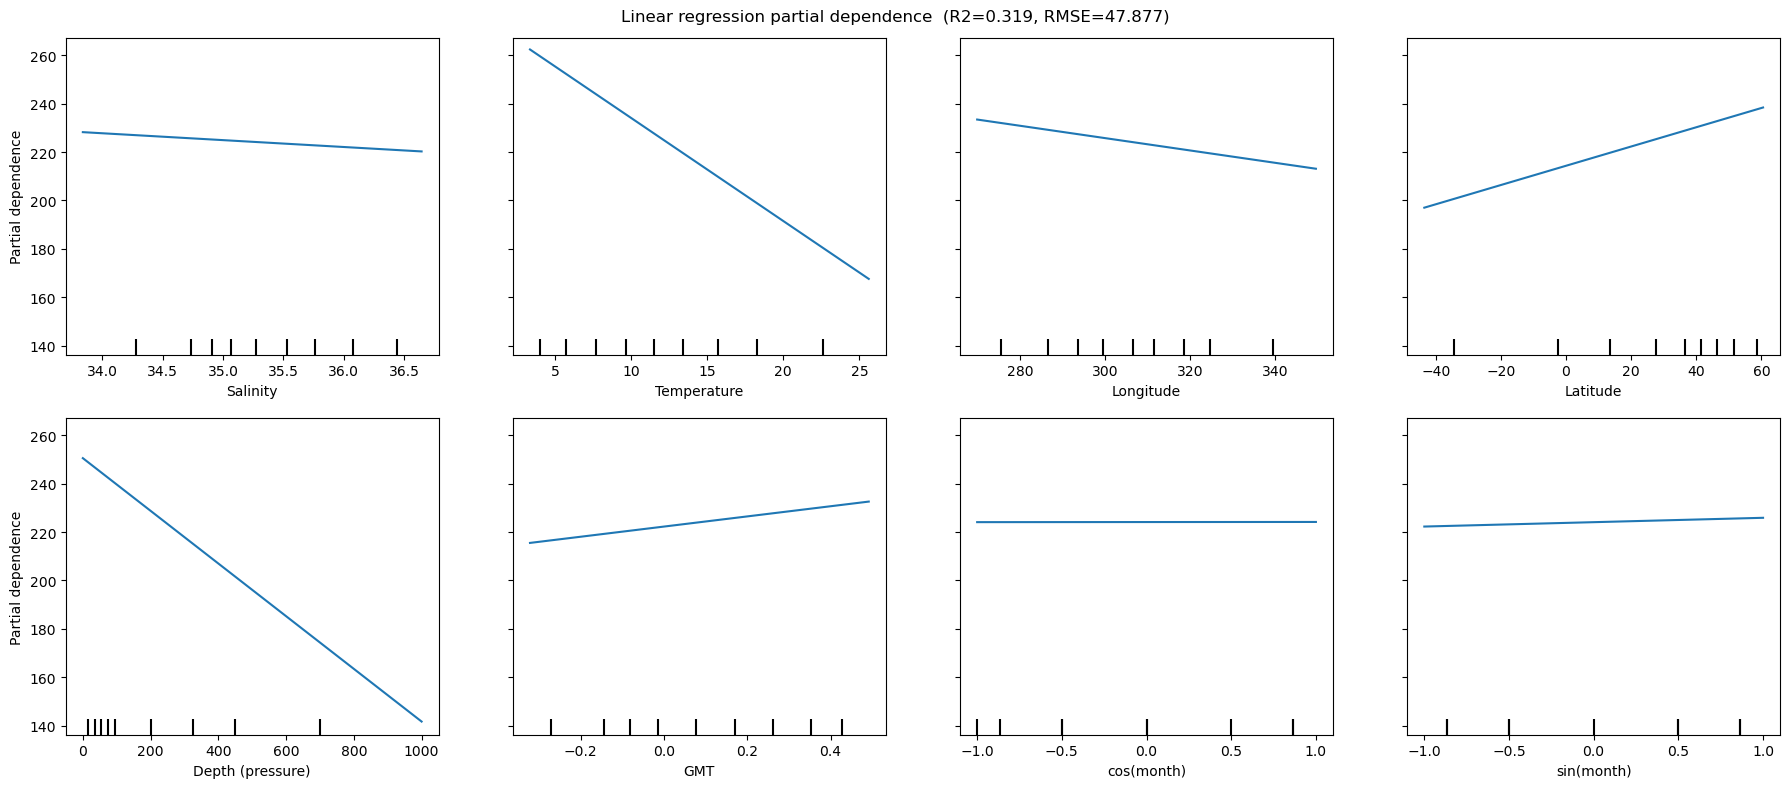

In [13]:
from sklearn.inspection import PartialDependenceDisplay

# PD is estimated by averaging predictions over a background sample; a random
# subsample is enough here since the model is linear (the marginal slope doesn't
# depend on sample size) and keeps this fast on ~2.8M training rows
rng = np.random.default_rng(seed)
pd_idx = rng.choice(X_train_eda.shape[0], size=min(20000, X_train_eda.shape[0]), replace=False)

fig, ax = plt.subplots(figsize=(18, 8))
disp = PartialDependenceDisplay.from_estimator(
    lr_model, X_train_eda[pd_idx], features=range(len(feature_names)),
    feature_names=feature_names, n_cols=4, ax=ax,
)
disp.figure_.suptitle(f'Linear regression partial dependence  (R2={R2_lr:.3f}, RMSE={RMSE_lr:.3f})')
plt.tight_layout()
plt.savefig('Fig_EDA_LinearRegression_PartialDependence.pdf')
plt.show()

## PyTorch MLP model
- Plain fully-connected network: `Linear -> ReLU` per hidden layer, single linear output unit.
- `weight_decay` in the Adam optimizer plays the same role as sklearn's `alpha` (L2 regularization).
- Folds are trained **sequentially** on the single shared GPU — each fit already saturates the GPU internally, and running several fits concurrently via multiprocessing would just contend for the same device.

In [14]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden_layer_sizes):
        super().__init__()
        layers = []
        n_prev = n_in
        for h in hidden_layer_sizes:
            layers.append(nn.Linear(n_prev, h))
            layers.append(nn.ReLU())
            n_prev = h
        layers.append(nn.Linear(n_prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def fit_mlp(X_tr, y_tr, hidden_layer_sizes, optim='SGD', weight_decay=0.01, \
            lr=1e-3, epochs=200, batch_size=4096, momentum = 0.9, nesterov = False, \
            betas=(0.9, 0.999), verbose=False, X_val=None, y_val=None, plot_live=False):
    # data is small enough to live on the GPU whole; mini-batching is done by
    # indexing GPU-resident tensors directly rather than via DataLoader, since
    # DataLoader's per-batch Python/host-transfer overhead dominates for a model
    # this small and makes the GPU no faster than plain CPU
    torch.manual_seed(seed)
    model = MLP(X_tr.shape[1], hidden_layer_sizes).to(device)
    if optim == 'SGD':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, nesterov=nesterov)
    elif optim == 'Adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay)
    elif optim == 'AdamW':
        opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=betas, eps=1e-8, weight_decay=weight_decay)
    #
    loss_fn = nn.MSELoss()
    #
    X_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
    n = X_t.shape[0]
    #
    # X_val/y_val are optional: pass a held-out split to also track validation
    # loss each epoch (e.g. for the final retrain, using the outer test set)
    has_val = X_val is not None
    if has_val:
        X_v = torch.tensor(X_val, dtype=torch.float32, device=device)
        y_v = torch.tensor(y_val, dtype=torch.float32, device=device)
    #
    train_losses = []
    val_losses = []
    # plot_live requires has_val (nothing to plot against otherwise) and redraws
    # a single figure in place every 10 epochs, notebook-only (uses IPython display)
    if plot_live and has_val:
        fig, ax = plt.subplots(figsize=(6, 4))
    #
    model.train()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            xb, yb = X_t[idx], y_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()*xb.size(0)
        train_losses.append(epoch_loss/n)
        # evaluate validation loss on the full held-out split (no mini-batching needed for eval)
        if has_val:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_v), y_v).item()
            val_losses.append(val_loss)
        if plot_live and has_val and ((epoch + 1) % 10 == 0 or epoch == epochs - 1):
            # display intermediate results
            clear_output(wait=True)
            ax.clear()
            ax.plot(np.arange(0, epoch+1, 1), train_losses, '-', color='b', label='Train')
            ax.plot(np.arange(0, epoch+1, 1), val_losses, '--', color='r', label='Valid')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.legend()
            display(fig)
            print(f'Epoch {epoch+1}/{epochs}  train loss={epoch_loss/n:.4f}')
        elif verbose and (epoch % 20 == 0 or epoch == epochs-1):
            msg = f'  epoch {epoch:4d}  train MSE = {epoch_loss/n:.5f}'
            if has_val:
                msg += f'  val MSE = {val_loss:.5f}'
            print(msg)
    if plot_live and has_val:
        plt.close(fig)
    model.train_losses = train_losses
    model.val_losses = val_losses
    return model


@torch.no_grad()
def predict_mlp(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    return model(X_t).cpu().numpy()

### Vanilla SGD as a baseline

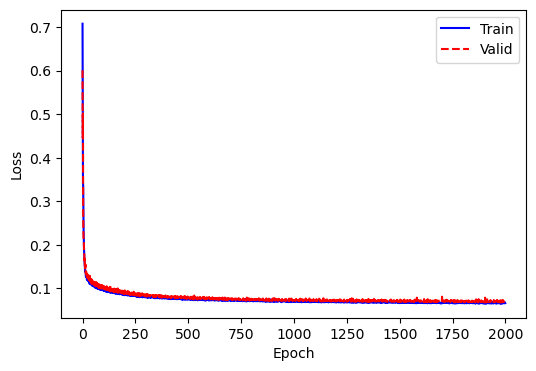

Epoch 2000/2000  train loss=0.0660
R2=0.9275  RMSE=15.6594


In [15]:
# single model training with all training data
#
model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
                momentum = 0, nesterov=False, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
#model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.01, lr=0.01, \
#                betas=(0.9,0.999), batch_size=100000, epochs=1000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
y_est = predict_mlp(model, X_test)
#
r = np.corrcoef(y_est, y_test)
R2=r[0,1]**2
RMSE=np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')

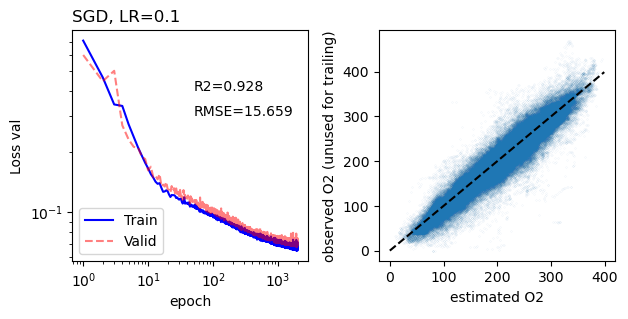

In [16]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,2001,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('SGD, LR=0.1',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')
#plt.savefig('Fig_AdamW_64_64_lr=1E-2_beta=0.9_0.999_wd=1e-2.pdf')
plt.savefig('Fig_SGD_baseline.pdf',bbox_inches='tight')

### SGD with Nesterov momentum = 0.9

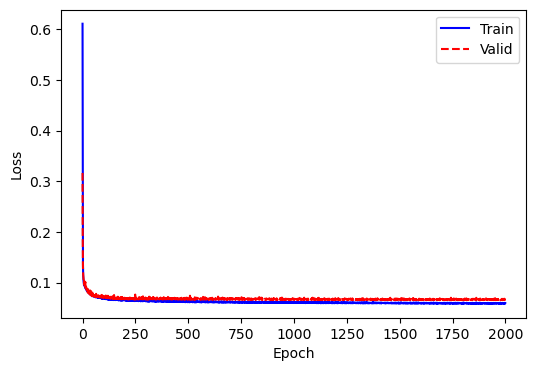

Epoch 2000/2000  train loss=0.0593
R2=0.9303  RMSE=15.2849


In [17]:
# single model training with all training data
#
model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
                momentum = 0.9, nesterov=True, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
#model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.01, lr=0.01, \
#                betas=(0.9,0.999), batch_size=100000, epochs=1000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
y_est = predict_mlp(model, X_test)
#
r = np.corrcoef(y_est, y_test)
R2=r[0,1]**2
RMSE=np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')

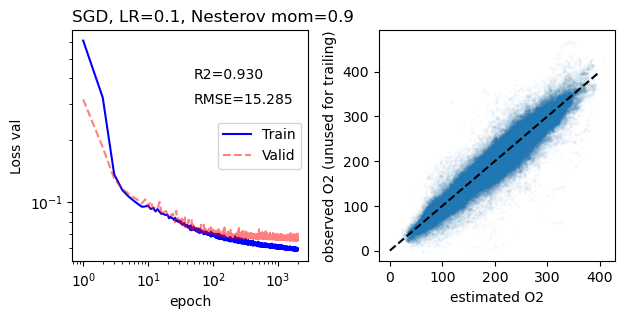

In [18]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,2001,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('SGD, LR=0.1, Nesterov mom=0.9',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig('Fig_SGD_Nesterov.pdf',bbox_inches='tight')

# Adam optimizer

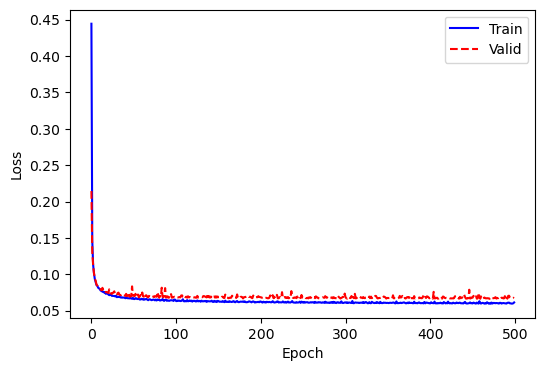

Epoch 500/500  train loss=0.0613
R2=0.9296  RMSE=15.4023


In [19]:
# single model training with all training data
#
#model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
#                momentum = 0.9, nesterov=True, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
model = fit_mlp(X_train, y_train, [64,64], optim='Adam', weight_decay = 0, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
y_est = predict_mlp(model, X_test)
#
r = np.corrcoef(y_est, y_test)
R2=r[0,1]**2
RMSE=np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')

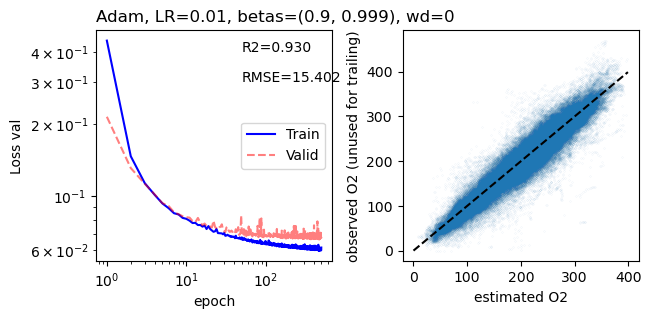

In [20]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,501,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('Adam, LR=0.01, betas=(0.9, 0.999), wd=0',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig('Fig_Adam_baseline.pdf',bbox_inches='tight')

## AdamW

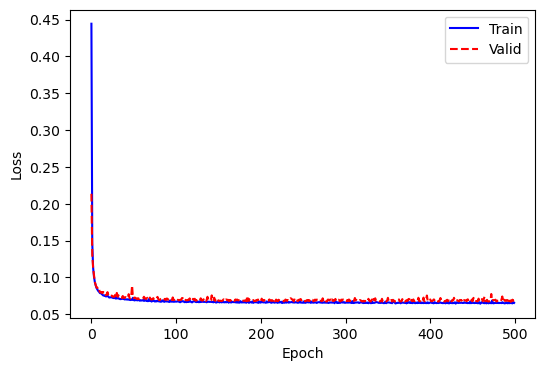

Epoch 500/500  train loss=0.0654
R2=0.9274  RMSE=15.5635


In [21]:
# single model training with all training data
#
#model = fit_mlp(X_train, y_train, [64,64], optim='SGD', weight_decay = 0, lr=.1, \
#                momentum = 0.9, nesterov=True, batch_size=100000, epochs=2000, verbose=True, X_val = X_test, y_val = y_test, \
#                plot_live=True)
model = fit_mlp(X_train, y_train, [64,64], optim='AdamW', weight_decay = 0.1, lr=0.01, \
                betas=(0.9,0.999), batch_size=100000, epochs=500, verbose=True, X_val = X_test, y_val = y_test, \
                plot_live=True)
y_est = predict_mlp(model, X_test)
#
r = np.corrcoef(y_est, y_test)
R2=r[0,1]**2
RMSE=np.sqrt(np.mean((y_est-y_test)**2))*ystd
print(f'R2={R2:.4f}  RMSE={RMSE:.4f}')

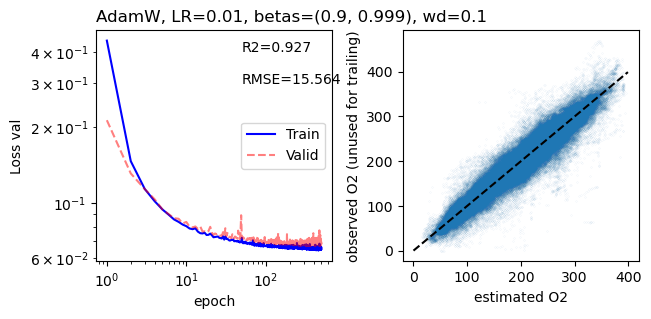

In [22]:
fig,ax=plt.subplots(1,2,figsize=(7,3))
plt.subplots_adjust(wspace=.3)

ep=np.arange(1,501,1)
ax[0].loglog(ep,model.train_losses, '-', color='b', label='Train')
ax[0].loglog(ep,model.val_losses, '--', color='r', label='Valid',alpha=.5)
ax[0].text(50,.4,f'R2={R2:.3f}')
ax[0].text(50,.3,f'RMSE={RMSE:.3f}')
#plt.title('Vanilla SGD, LR=0.1, Momentum=0')
ax[0].set_title('AdamW, LR=0.01, betas=(0.9, 0.999), wd=0.1',loc='left')
#plt.title('AdamW [64,32], LR=0.01, betas=(0.9, 0.999), wd=0.01')
ax[0].legend()
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Loss val')

ax[1].plot(y_est*ystd+ym,y_test*ystd+ym,'.',markersize=.1,alpha=.5)
ax[1].plot(np.arange(0,400,1),np.arange(0,400,1),'--',color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2 (unused for trailing)')

plt.savefig('Fig_AdamW_baseline.pdf',bbox_inches='tight')

## Sensitivity study: is the model just learning climatology?
- Concern: lon/lat/depth/season alone already define a strong climatological prior for dissolved O2, so high skill could come mostly from those coordinates rather than from the time-evolving ocean state — which would mean the model isn't really capturing interannual/decadal dynamics.
- GMT (global mean temperature) evolves over time, so leaving it in the "climatology-only" set would let time-evolving information leak back in through the back door. This version drops Salinity, Temperature, **and GMT**, keeping only lon, lat, depth, cos/sin(month) — a truly static climatology with no time-varying information at all.
- Refit both the linear regression baseline and an MLP (same architecture/optimizer as the Adam run above) on the same train/test split, and compare against the full-feature results.
- If R2 barely drops, the full model is mostly reproducing a static climatology; a large drop indicates the time-evolving predictors (T, S, GMT) carry real predictive information beyond position and season.

In [23]:
# build the pure-climatology (no T/S/GMT) feature set, in both the standardized
# form used by the MLP and the raw-unit form used by the linear regression
clim_idx = [i for i, n in enumerate(feature_names) if n not in ('Salinity', 'Temperature', 'GMT')]
feature_names_clim = [feature_names[i] for i in clim_idx]
print('Climatology-only features:', feature_names_clim)

X_train_clim = X_train[:, clim_idx]
X_test_clim = X_test[:, clim_idx]

X_train_eda_clim = X_train_eda[:, clim_idx]
X_test_lr_clim = X_test_lr[:, clim_idx]

Climatology-only features: ['Longitude', 'Latitude', 'Depth (pressure)', 'cos(month)', 'sin(month)']


In [24]:
lr_model_clim = LinearRegression()
lr_model_clim.fit(X_train_eda_clim, y_train_eda)

y_est_lr_clim = lr_model_clim.predict(X_test_lr_clim)
r_lr_clim = np.corrcoef(y_est_lr_clim, y_test_lr)
R2_lr_clim = r_lr_clim[0, 1]**2
RMSE_lr_clim = np.sqrt(np.mean((y_est_lr_clim - y_test_lr)**2))

print(f'Linear Regression, full features   : R2={R2_lr:.4f}  RMSE={RMSE_lr:.4f}')
print(f'Linear Regression, no T/S/GMT       : R2={R2_lr_clim:.4f}  RMSE={RMSE_lr_clim:.4f}')

Linear Regression, full features   : R2=0.3185  RMSE=47.8771
Linear Regression, no T/S/GMT       : R2=0.1356  RMSE=53.8411


In [25]:
# refit the MLP from scratch on both feature sets with identical hyperparameters
# (same Adam config as the "Adam optimizer" section above) for a clean, apples-to-apples
# comparison, rather than relying on the R2/RMSE/model globals left over from earlier cells
mlp_kwargs = dict(hidden_layer_sizes=[64, 64], optim='Adam', weight_decay=0, lr=0.01, \
                   betas=(0.9, 0.999), batch_size=100000, epochs=500, verbose=True)

print('--- full features (T, S, GMT included) ---')
model_full = fit_mlp(X_train, y_train, X_val=X_test, y_val=y_test, **mlp_kwargs)
y_est_full = predict_mlp(model_full, X_test)
r_full = np.corrcoef(y_est_full, y_test)
R2_mlp_full = r_full[0, 1]**2
RMSE_mlp_full = np.sqrt(np.mean((y_est_full - y_test)**2))*ystd
print(f'MLP (Adam), full features : R2={R2_mlp_full:.4f}  RMSE={RMSE_mlp_full:.4f}')

print('--- climatology-only features (no T/S/GMT) ---')
model_clim = fit_mlp(X_train_clim, y_train, X_val=X_test_clim, y_val=y_test, **mlp_kwargs)
y_est_clim = predict_mlp(model_clim, X_test_clim)
r_clim = np.corrcoef(y_est_clim, y_test)
R2_mlp_clim = r_clim[0, 1]**2
RMSE_mlp_clim = np.sqrt(np.mean((y_est_clim - y_test)**2))*ystd
print(f'MLP (Adam), no T/S/GMT    : R2={R2_mlp_clim:.4f}  RMSE={RMSE_mlp_clim:.4f}')

--- full features (T, S, GMT included) ---
  epoch    0  train MSE = 0.44437  val MSE = 0.21435


  epoch   20  train MSE = 0.07219  val MSE = 0.07422


  epoch   40  train MSE = 0.06699  val MSE = 0.07044


  epoch   60  train MSE = 0.06547  val MSE = 0.07495


  epoch   80  train MSE = 0.06474  val MSE = 0.06767


...

  epoch  420  train MSE = 0.07725  val MSE = 0.08687


  epoch  440  train MSE = 0.08147  val MSE = 0.08431


  epoch  460  train MSE = 0.07910  val MSE = 0.08686


  epoch  480  train MSE = 0.08071  val MSE = 0.08440


  epoch  499  train MSE = 0.07719  val MSE = 0.08437
MLP (Adam), no T/S/GMT    : R2=0.9110  RMSE=17.2490


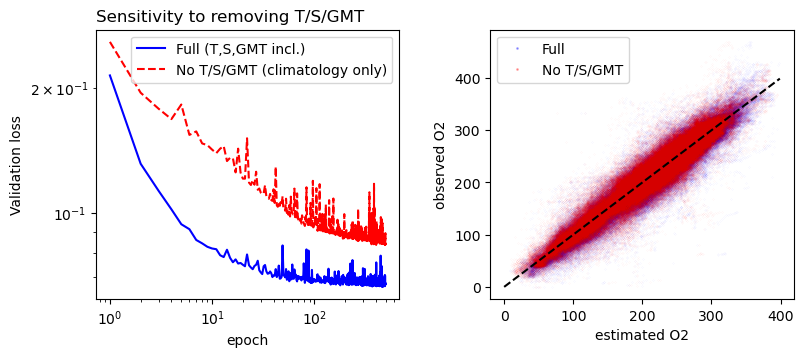

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
plt.subplots_adjust(wspace=.3)

ep = np.arange(1, len(model_full.val_losses)+1)
ax[0].loglog(ep, model_full.val_losses, '-', color='b', label='Full (T,S,GMT incl.)')
ax[0].loglog(ep, model_clim.val_losses, '--', color='r', label='No T/S/GMT (climatology only)')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('Validation loss')
ax[0].set_title('Sensitivity to removing T/S/GMT', loc='left')
ax[0].legend()

ax[1].plot(y_est_full*ystd+ym, y_test*ystd+ym, '.', markersize=.1, alpha=.3, color='b', label='Full')
ax[1].plot(y_est_clim*ystd+ym, y_test*ystd+ym, '.', markersize=.1, alpha=.3, color='r', label='No T/S/GMT')
ax[1].plot(np.arange(0, 400, 1), np.arange(0, 400, 1), '--', color='k')
ax[1].set_xlabel('estimated O2')
ax[1].set_ylabel('observed O2')
ax[1].legend(markerscale=20)

plt.savefig('Fig_sensitivity_noTSGMT.pdf', bbox_inches='tight')
plt.show()

In [27]:
summary = pd.DataFrame({
    'model': ['Linear Regression', 'Linear Regression', 'MLP (Adam)', 'MLP (Adam)'],
    'features': ['full (T,S,GMT incl.)', 'no T/S/GMT (pure climatology)', 'full (T,S,GMT incl.)', 'no T/S/GMT (pure climatology)'],
    'R2': [R2_lr, R2_lr_clim, R2_mlp_full, R2_mlp_clim],
    'RMSE': [RMSE_lr, RMSE_lr_clim, RMSE_mlp_full, RMSE_mlp_clim],
})
display(summary)

,model,features,R2,RMSE
0,Linear Regression,"full (T,S,GMT incl.)",0.318517,47.877102
1,Linear Regression,no T/S/GMT (pure climatology),0.135625,53.841124
2,MLP (Adam),"full (T,S,GMT incl.)",0.929585,15.402303
3,MLP (Adam),no T/S/GMT (pure climatology),0.910976,17.248970
